# Libraries

This section imports the Python libraries used for data loading, preprocessing, visualization, feature engineering, and later machine learning experiments.

In [2]:
import pandas as pd
import numpy as np
import ast
import re

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from collections import Counter
from itertools import combinations

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.decomposition import NMF, TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor

from IPython.display import display

# Data Loading

The study uses three datasets:

1. `data_jobs.csv` as the main international job postings dataset
2. `FIES2015 - LFSJAN16 CSV - Cleaned.csv` as the Philippine local dataset for contextual validation
3. `world_bank_data_2025.csv` as the country-level macroeconomic dataset

At this stage, the datasets are loaded and inspected to confirm that they were read correctly.

In [3]:
# Main international job postings dataset
jobs = pd.read_csv("data_jobs.csv")

# Philippine local dataset (reserved for later external validation)
lfs = pd.read_csv("FIES2015 - LFSJAN16 CSV - Cleaned.csv", low_memory=False)

# World Bank country-level context data
econ = pd.read_csv("world_bank_data_2025.csv")

print("jobs shape:", jobs.shape)
print("lfs shape:", lfs.shape)
print("econ shape:", econ.shape)

display(jobs.head())

jobs shape: (785741, 17)
lfs shape: (207212, 154)
econ shape: (3472, 16)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


In [4]:
print("Jobs columns:")
display(pd.Series(jobs.columns))

print("\nJobs info:")
jobs.info()

Jobs columns:


0           job_title_short
1                 job_title
2              job_location
3                   job_via
4         job_schedule_type
5        job_work_from_home
6           search_location
7           job_posted_date
8     job_no_degree_mention
9      job_health_insurance
10              job_country
11              salary_rate
12          salary_year_avg
13          salary_hour_avg
14             company_name
15               job_skills
16          job_type_skills
dtype: object


Jobs info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   job_title_short        785741 non-null  object 
 1   job_title              785740 non-null  object 
 2   job_location           784696 non-null  object 
 3   job_via                785733 non-null  object 
 4   job_schedule_type      773074 non-null  object 
 5   job_work_from_home     785741 non-null  bool   
 6   search_location        785741 non-null  object 
 7   job_posted_date        785741 non-null  object 
 8   job_no_degree_mention  785741 non-null  bool   
 9   job_health_insurance   785741 non-null  bool   
 10  job_country            785692 non-null  object 
 11  salary_rate            33067 non-null   object 
 12  salary_year_avg        22003 non-null   float64
 13  salary_hour_avg        10662 non-null   float64
 14  company_name           7

In [5]:
print("LFS columns:")
display(pd.Series(lfs.columns[:30]))

print("\nWorld Bank columns:")
display(pd.Series(econ.columns))

LFS columns:


0                id
1            person
2            w_regn
3          other_id
4             rfact
5           pop_adj
6               urb
7              tstr
8              tpsu
9             pcinc
10             rstr
11             rpsu
12            fsize
13         agri_sal
14      nonagri_sal
15            wages
16         netshare
17      cash_abroad
18    cash_domestic
19      rentals_rec
20         interest
21          pension
22        dividends
23     other_source
24      net_receipt
25            regft
26          net_cfg
27          net_lpr
28         net_fish
29          net_for
dtype: object


World Bank columns:


0                        country_name
1                          country_id
2                                year
3                   Inflation (CPI %)
4                   GDP (Current USD)
5        GDP per Capita (Current USD)
6               Unemployment Rate (%)
7             Interest Rate (Real, %)
8         Inflation (GDP Deflator, %)
9               GDP Growth (% Annual)
10    Current Account Balance (% GDP)
11      Government Expense (% of GDP)
12      Government Revenue (% of GDP)
13             Tax Revenue (% of GDP)
14        Gross National Income (USD)
15             Public Debt (% of GDP)
dtype: object

# Data Preprocessing

This section prepares the main job postings dataset for analysis and later modeling.

The preprocessing pipeline includes:

- country standardization
- integration of World Bank country-level features
- salary normalization
- outlier removal
- log transformation of salary
- skill cleaning and parsing
- engineering of skill-category count features
- regional grouping
- filtering of rare job titles

In [6]:
# -------------------------
# COUNTRY STANDARDIZATION
# -------------------------
country_map = {
    "Russia": "Russian Federation",
    "Vietnam": "Viet Nam",
    "South Korea": "Korea, Rep.",
    "North Korea": "Korea, Dem. People's Rep.",
    "Egypt": "Egypt, Arab Rep.",
    "Côte d'Ivoire": "Cote d'Ivoire",
    "Iran": "Iran, Islamic Rep.",
    "Venezuela": "Venezuela, RB",
    "Slovakia": "Slovak Republic",
    "Hong Kong": "Hong Kong SAR, China",
    "Macedonia (FYROM)": "North Macedonia",
    "Palestine": "West Bank and Gaza",
    "Laos": "Lao PDR",
    "Syria": "Syrian Arab Republic",
    "Turkey": "Turkiye",
    "Yemen": "Yemen, Rep.",
    "United States Virgin Islands": "Virgin Islands (U.S.)",
    "Bahamas": "Bahamas, The",
    "Brunei": "Brunei Darussalam",
    "Congo, Democratic Republic of the": "Congo, Dem. Rep.",
    "Curaçao": "Curacao",
    "Gambia": "Gambia, The",
    "Kyrgyzstan": "Kyrgyz Republic",
    "Taiwan": "Taiwan, China",
    "U.S. Virgin Islands": "Virgin Islands (U.S.)"
}

In [7]:
# -------------------------
# WORLD BANK 2023 FEATURES
# -------------------------
econ_2023 = econ[econ["year"] == 2023].copy()

econ_2023 = econ_2023[[
    "country_name",
    "GDP per Capita (Current USD)",
    "GDP (Current USD)",
    "Unemployment Rate (%)",
    "Inflation (CPI %)",
    "GDP Growth (% Annual)"
]]

# interest rate, gross national income (USD)

econ_2023.columns = [
    "country",
    "gdp_per_capita",
    "gdp",
    "unemployment",
    "inflation",
    "gdp_growth"
]

display(econ_2023.head())

,country,gdp_per_capita,gdp,unemployment,inflation,gdp_growth
13,Aruba,33984.790620,3.648573e+09,NaN,NaN,4.263719
29,Afghanistan,415.707417,1.723305e+10,13.991,-4.644709,2.710887
45,Angola,2308.159767,8.482465e+10,14.537,13.644102,1.001289
61,Albania,8575.171134,2.354718e+10,10.108,4.759764,3.936625
77,Andorra,46812.448449,3.785067e+09,NaN,NaN,2.583555


Only the columns directly relevant to salary prediction, skill representation, and job context are retained from the main dataset.

In [8]:
# -------------------------
# KEEP USEFUL COLUMNS
# -------------------------
wanted_cols = [
    "job_title_short",
    "job_title",
    "job_location",
    "job_via",
    "job_schedule_type",
    "job_work_from_home",
    "job_no_degree_mention",
    "job_health_insurance",
    "job_country",
    "salary_rate",
    "salary_year_avg",
    "salary_hour_avg",
    "company_name",
    "job_skills",
    "job_type_skills"
]

existing_cols = [c for c in wanted_cols if c in jobs.columns]

jobs_model = jobs[existing_cols].copy()

# standardize country names
jobs_model["job_country"] = jobs_model["job_country"].replace(country_map)

# merge economic features
jobs_model = jobs_model.merge(
    econ_2023,
    left_on="job_country",
    right_on="country",
    how="left"
)

# fill numeric macroeconomic missings with median
for col in ["gdp_per_capita", "gdp", "unemployment", "inflation", "gdp_growth"]:
    if col in jobs_model.columns:
        jobs_model[col] = jobs_model[col].fillna(jobs_model[col].median())

print("jobs_model shape after merge:", jobs_model.shape)
display(jobs_model.head())

jobs_model shape after merge: (785741, 21)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,salary_hour_avg,company_name,job_skills,job_type_skills,country,gdp_per_capita,gdp,unemployment,inflation,gdp_growth
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,False,False,United States,NaN,...,NaN,Boehringer Ingelheim,NaN,NaN,United States,82769.412211,2.772071e+13,3.638,4.116338,2.887556
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,False,False,Mexico,NaN,...,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr...",Mexico,13790.024343,1.789114e+12,2.765,5.527961,3.199981
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,False,False,Germany,NaN,...,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],...",Germany,54343.226508,4.525704e+12,3.068,5.946437,-0.266438
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,True,False,United States,NaN,...,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",United States,82769.412211,2.772071e+13,3.638,4.116338,2.887556
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,False,False,Sudan,NaN,...,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl...",Sudan,2183.441406,1.092655e+11,3.668,4.311282,-20.111576


A unified annual salary variable is created. If annual salary is unavailable, hourly salary is converted using a 40-hour work week and 52 weeks per year.

In [9]:
# -------------------------
# TARGET SALARY
# -------------------------
def get_salary(row):
    if pd.notna(row.get("salary_year_avg")):
        return row["salary_year_avg"]
    if pd.notna(row.get("salary_hour_avg")):
        return row["salary_hour_avg"] * 40 * 52
    return np.nan

jobs_model["salary"] = jobs_model.apply(get_salary, axis=1)
jobs_model = jobs_model.dropna(subset=["salary"]).copy()

print("Shape after removing missing salaries:", jobs_model.shape)

Shape after removing missing salaries: (32665, 22)


In [10]:
# remove salary outliers (IQR)
Q1 = jobs_model["salary"].quantile(0.25)
Q3 = jobs_model["salary"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

jobs_model = jobs_model[
    (jobs_model["salary"] >= lower) &
    (jobs_model["salary"] <= upper)
].copy()

jobs_model["salary_log"] = np.log1p(jobs_model["salary"])

print("Shape after outlier removal:", jobs_model.shape)
print("Salary summary:")
display(jobs_model["salary"].describe())

Shape after outlier removal: (32186, 23)
Salary summary:


count     32186.000000
mean     112195.970542
std       42660.262435
min       15000.000000
25%       80850.000000
50%      110000.000000
75%      142500.000000
max      241000.000000
Name: salary, dtype: float64

In [11]:
# -------------------------
# ADD ENGINEERED ECON FEATURES
# -------------------------
jobs_model["gdp_per_capita_log"] = np.log1p(jobs_model["gdp_per_capita"])
jobs_model["gdp_log"] = np.log1p(jobs_model["gdp"])
jobs_model["labor_market_tightness"] = 1 - jobs_model["unemployment"]
jobs_model["real_gdp_per_capita"] = jobs_model["gdp_per_capita"] / (1 + jobs_model["inflation"] / 100)

The `job_skills` column is cleaned and converted into a standardized list of lowercase skills for each posting.

In [12]:
# -------------------------
# CLEAN SKILLS
# -------------------------
def clean_skills(x):
    if isinstance(x, list):
        all_items = []
        for item in x:
            text = str(item).strip().strip("'\"[]")
            parts = re.split(r",\s*", text)
            all_items.extend(parts)
        return [s.strip().strip("'\" ").lower() for s in all_items if s.strip()]
    
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return clean_skills(parsed)
        except:
            pass
        x_clean = x.strip().strip("[]")
        parts = re.split(r",\s*", x_clean)
        return [s.strip().strip("'\" ").lower() for s in parts if s.strip()]
    
    return []

jobs_model["skills_list"] = jobs_model["job_skills"].apply(clean_skills)
jobs_model["skills_list"] = jobs_model["skills_list"].apply(lambda x: list(dict.fromkeys(x)))
jobs_model["skill_count"] = jobs_model["skills_list"].apply(len)

display(jobs_model[["job_skills", "skills_list", "skill_count"]].head(10))

,job_skills,skills_list,skill_count
28,"['gdpr', 'excel']","[gdpr, excel]",2
43,"['sql', 'sql server']","[sql, sql server]",2
51,"['python', 'java', 'aws', 'databricks', 'spark']","[python, java, aws, databricks, spark]",5
77,"['mongodb', 'mongodb', 'python', 'r', 'sql', '...","[mongodb, python, r, sql, mysql, mariadb, orac...",10
92,"['sql', 'python']","[sql, python]",2
100,"['sql', 'r', 'python', 'express']","[sql, r, python, express]",4
109,"['python', 'r', 'alteryx', 'tableau']","[python, r, alteryx, tableau]",4
116,"['r', 'python', 'sql', 't-sql', 'hadoop', 'spa...","[r, python, sql, t-sql, hadoop, spark, tableau]",7
146,"['golang', 'scala', 'python', 'java', 'hadoop'...","[golang, scala, python, java, hadoop, spark]",6
180,"['excel', 'powerpoint']","[excel, powerpoint]",2


The `job_type_skills` column contains grouped skill categories. These are parsed to create count-based features for skill families such as analyst tools, cloud tools, databases, and programming languages.

In [13]:
# -------------------------
# PARSE job_type_skills
# -------------------------
def parse_skill_dict(x):
    if isinstance(x, dict):
        return x
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return {}
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            return parsed if isinstance(parsed, dict) else {}
        except:
            return {}
    return {}

jobs_model["job_type_skills_parsed"] = jobs_model["job_type_skills"].apply(parse_skill_dict)

skill_type_categories = [
    "analyst_tools", "cloud", "libraries", "databases", "programming",
    "other", "webframeworks", "os", "async", "sync"
]

for cat in skill_type_categories:
    jobs_model[f"{cat}_count"] = jobs_model["job_type_skills_parsed"].apply(
        lambda d: len(d.get(cat, [])) if isinstance(d, dict) else 0
    )

jobs_model["num_skill_categories"] = jobs_model["job_type_skills_parsed"].apply(
    lambda d: len([k for k, v in d.items() if isinstance(v, list) and len(v) > 0]) if isinstance(d, dict) else 0
)

display(
    jobs_model[
        ["job_type_skills", "job_type_skills_parsed"] +
        [f"{cat}_count" for cat in skill_type_categories] +
        ["num_skill_categories"]
    ].head(10)
)

,job_type_skills,job_type_skills_parsed,analyst_tools_count,cloud_count,libraries_count,databases_count,programming_count,other_count,webframeworks_count,os_count,async_count,sync_count,num_skill_categories
28,"{'analyst_tools': ['excel'], 'libraries': ['gd...","{'analyst_tools': ['excel'], 'libraries': ['gd...",1,0,1,0,0,0,0,0,0,0,2
43,"{'databases': ['sql server'], 'programming': [...","{'databases': ['sql server'], 'programming': [...",0,0,0,1,1,0,0,0,0,0,2
51,"{'cloud': ['aws', 'databricks'], 'libraries': ...","{'cloud': ['aws', 'databricks'], 'libraries': ...",0,2,1,0,2,0,0,0,0,0,3
77,"{'analyst_tools': ['tableau'], 'cloud': ['orac...","{'analyst_tools': ['tableau'], 'cloud': ['orac...",1,1,1,3,4,1,0,0,0,0,6
92,"{'programming': ['sql', 'python']}","{'programming': ['sql', 'python']}",0,0,0,0,2,0,0,0,0,0,1
100,"{'programming': ['sql', 'r', 'python'], 'webfr...","{'programming': ['sql', 'r', 'python'], 'webfr...",0,0,0,0,3,0,1,0,0,0,2
109,"{'analyst_tools': ['alteryx', 'tableau'], 'pro...","{'analyst_tools': ['alteryx', 'tableau'], 'pro...",2,0,0,0,2,0,0,0,0,0,2
116,"{'analyst_tools': ['tableau'], 'libraries': ['...","{'analyst_tools': ['tableau'], 'libraries': ['...",1,0,2,0,4,0,0,0,0,0,3
146,"{'libraries': ['hadoop', 'spark'], 'programmin...","{'libraries': ['hadoop', 'spark'], 'programmin...",0,0,2,0,4,0,0,0,0,0,2
180,"{'analyst_tools': ['excel', 'powerpoint']}","{'analyst_tools': ['excel', 'powerpoint']}",2,0,0,0,0,0,0,0,0,0,1


In [14]:
# -------------------------
# REGION GROUPING
# -------------------------
region_map = {
    "United States": "NA", "Canada": "NA",
    "Mexico": "LATAM", "Costa Rica": "LATAM", "Guatemala": "LATAM", "Panama": "LATAM",
    "Brazil": "LATAM", "Argentina": "LATAM", "Chile": "LATAM", "Peru": "LATAM",
    "United Kingdom": "EU", "Germany": "EU", "France": "EU", "Spain": "EU", "Italy": "EU",
    "Belgium": "EU", "Denmark": "EU", "Poland": "EU", "Portugal": "EU", "Sweden": "EU",
    "Netherlands": "EU", "Ireland": "EU", "Austria": "EU", "Romania": "EU", "Finland": "EU",
    "Switzerland": "EU", "Norway": "EU",
    "Philippines": "SEA", "Singapore": "SEA", "Indonesia": "SEA", "Malaysia": "SEA",
    "Thailand": "SEA", "Viet Nam": "SEA", "Brunei Darussalam": "SEA",
    "Japan": "EAST_ASIA", "Korea, Rep.": "EAST_ASIA", "Taiwan, China": "EAST_ASIA", "China": "EAST_ASIA",
    "India": "SOUTH_ASIA", "Pakistan": "SOUTH_ASIA", "Bangladesh": "SOUTH_ASIA",
    "United Arab Emirates": "ME", "Israel": "ME", "Jordan": "ME", "Turkiye": "ME",
    "South Africa": "AFRICA", "Nigeria": "AFRICA", "Kenya": "AFRICA", "Morocco": "AFRICA", "Egypt, Arab Rep.": "AFRICA",
    "Australia": "OCEANIA", "New Zealand": "OCEANIA"
}

jobs_model["region"] = jobs_model["job_country"].map(region_map).fillna("OTHER")

In [15]:
# -------------------------
# FILTER RARE TITLES
# -------------------------
title_counts = jobs_model["job_title_short"].value_counts()
common_titles = title_counts[title_counts >= 100].index

jobs_model = jobs_model[jobs_model["job_title_short"].isin(common_titles)].copy()

print("Final modeling dataframe shape:", jobs_model.shape)
display(jobs_model.head())

Final modeling dataframe shape: (32101, 42)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,libraries_count,databases_count,programming_count,other_count,webframeworks_count,os_count,async_count,sync_count,num_skill_categories,region
28,Data Scientist,CRM Data Specialist,"San José Province, San José, Costa Rica",via Ai-Jobs.net,Full-time,False,False,False,Costa Rica,year,...,1,0,0,0,0,0,0,0,2,LATAM
43,Senior Data Engineer,Sr SQL Database Engineer with Data Warehouse /...,NaN,via LinkedIn,Contractor,False,True,False,United States,hour,...,0,1,1,0,0,0,0,0,2,NA
51,Senior Data Engineer,Senior Data Engineer,Anywhere,via LinkedIn,Contractor,True,False,False,United States,hour,...,1,0,2,0,0,0,0,0,3,NA
77,Data Engineer,Data Engineer,"Arlington, VA",via LinkedIn,Full-time,False,False,False,Sudan,year,...,1,3,4,1,0,0,0,0,6,OTHER
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,False,True,United States,year,...,0,0,2,0,0,0,0,0,1,NA


# Exploratory Data Analysis (EDA)

Before building predictive models, exploratory data analysis is conducted to verify the correctness of preprocessing and to better understand the structure of the dataset.

The EDA focuses on:
- dataset structure and missingness
- salary distribution before and after log transformation
- job title distribution
- skill count distribution
- most common technical skills
- region distribution
- relationships between selected features and salary

This step helps assess whether preprocessing and feature engineering produced meaningful data for modeling.

In [16]:
print("Dataset shape:", jobs_model.shape)

print("\nColumns:")
display(pd.Series(jobs_model.columns))

print("\nMissing values:")
display(jobs_model.isna().sum().sort_values(ascending=False).head(20))

Dataset shape: (32101, 42)

Columns:


0            job_title_short
1                  job_title
2               job_location
3                    job_via
4          job_schedule_type
5         job_work_from_home
6      job_no_degree_mention
7       job_health_insurance
8                job_country
9                salary_rate
10           salary_year_avg
11           salary_hour_avg
12              company_name
13                job_skills
14           job_type_skills
15                   country
16            gdp_per_capita
17                       gdp
18              unemployment
19                 inflation
20                gdp_growth
21                    salary
22                salary_log
23        gdp_per_capita_log
24                   gdp_log
25    labor_market_tightness
26       real_gdp_per_capita
27               skills_list
28               skill_count
29    job_type_skills_parsed
30       analyst_tools_count
31               cloud_count
32           libraries_count
33           databases_count
34         pro


Missing values:


salary_hour_avg          21524
salary_year_avg          10577
job_type_skills           3122
job_skills                3122
job_location               336
job_schedule_type          140
country                     30
job_via                      8
job_title                    0
job_title_short              0
salary_rate                  0
job_country                  0
job_health_insurance         0
job_no_degree_mention        0
job_work_from_home           0
company_name                 0
gdp_per_capita               0
gdp                          0
unemployment                 0
inflation                    0
dtype: int64

The following plots examine the salary distribution before and after log transformation. This helps confirm whether the target variable has been appropriately stabilized for later modeling.

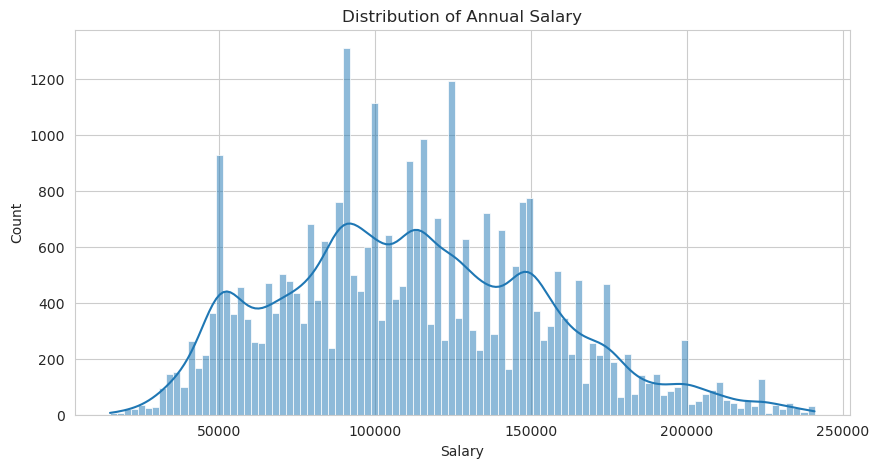

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(jobs_model["salary"], bins=100, kde=True)
plt.title("Distribution of Annual Salary")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

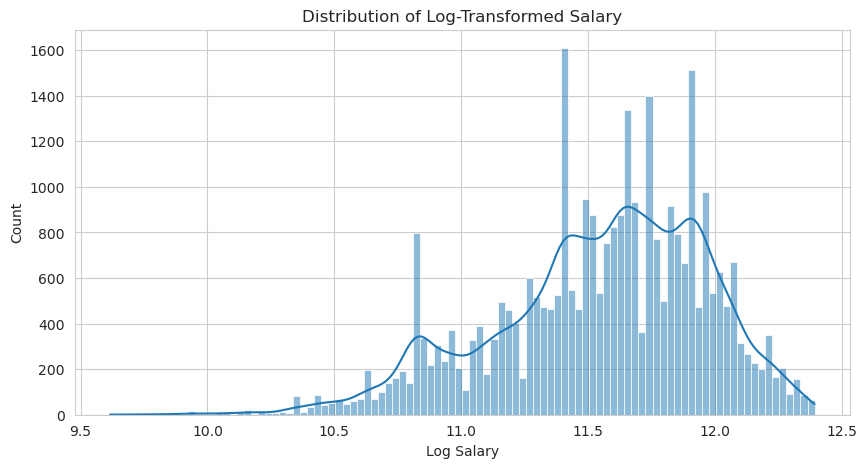

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(jobs_model["salary_log"], bins=100, kde=True)
plt.title("Distribution of Log-Transformed Salary")
plt.xlabel("Log Salary")
plt.ylabel("Count")
plt.show()

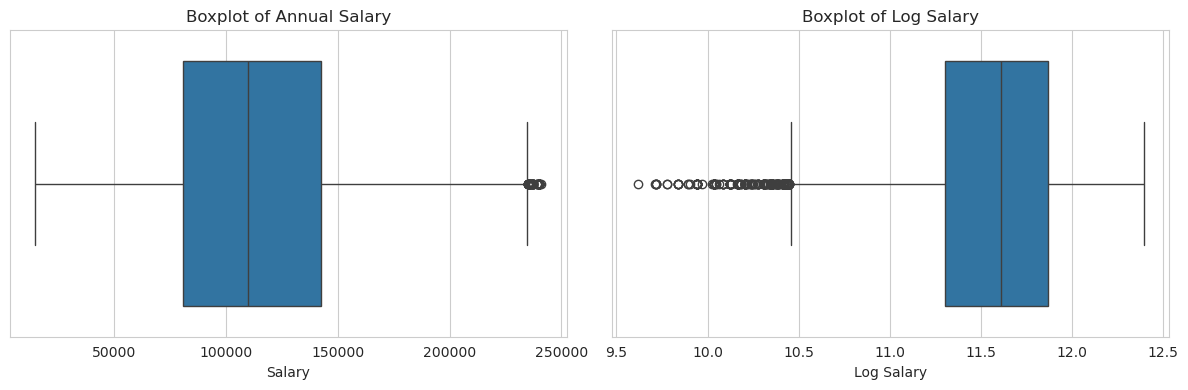

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=jobs_model["salary"], ax=axes[0])
axes[0].set_title("Boxplot of Annual Salary")
axes[0].set_xlabel("Salary")

sns.boxplot(x=jobs_model["salary_log"], ax=axes[1])
axes[1].set_title("Boxplot of Log Salary")
axes[1].set_xlabel("Log Salary")

plt.tight_layout()
plt.show()

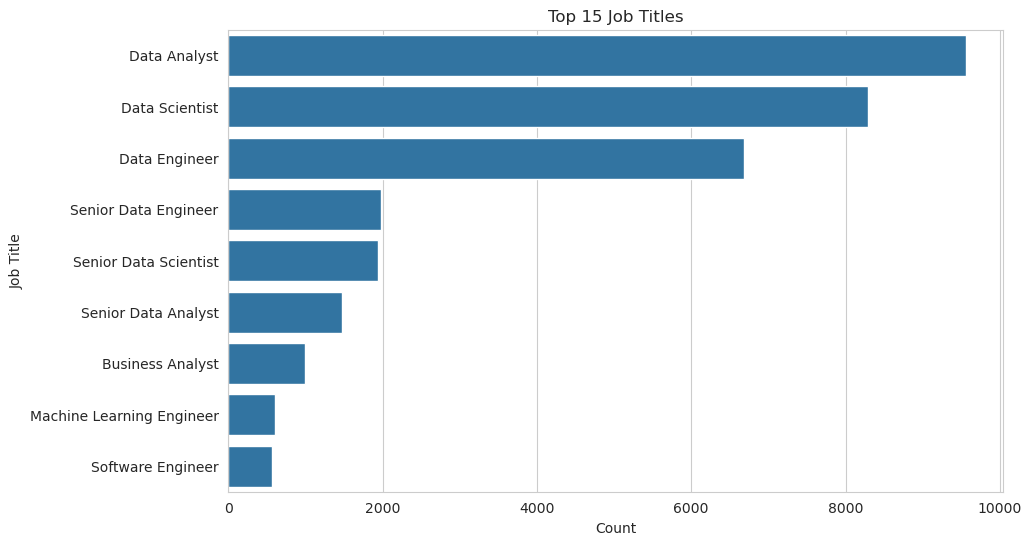

In [20]:
top_titles = jobs_model["job_title_short"].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_titles.values, y=top_titles.index)
plt.title("Top 15 Job Titles")
plt.xlabel("Count")
plt.ylabel("Job Title")
plt.show()

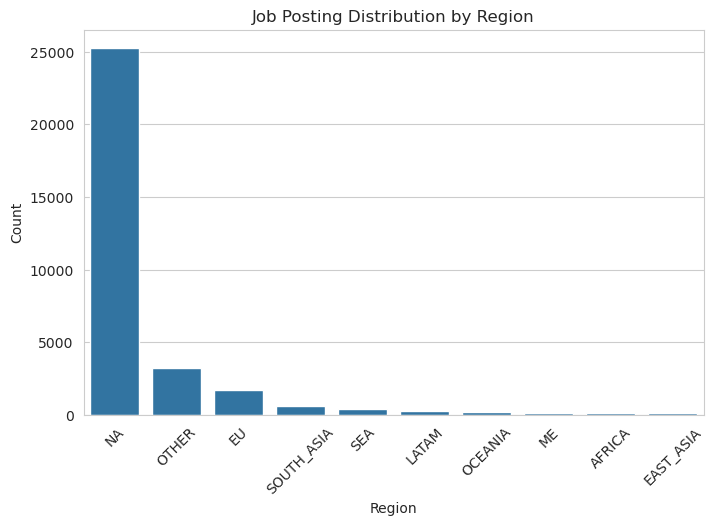

In [21]:
top_regions = jobs_model["region"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=top_regions.index, y=top_regions.values)
plt.title("Job Posting Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

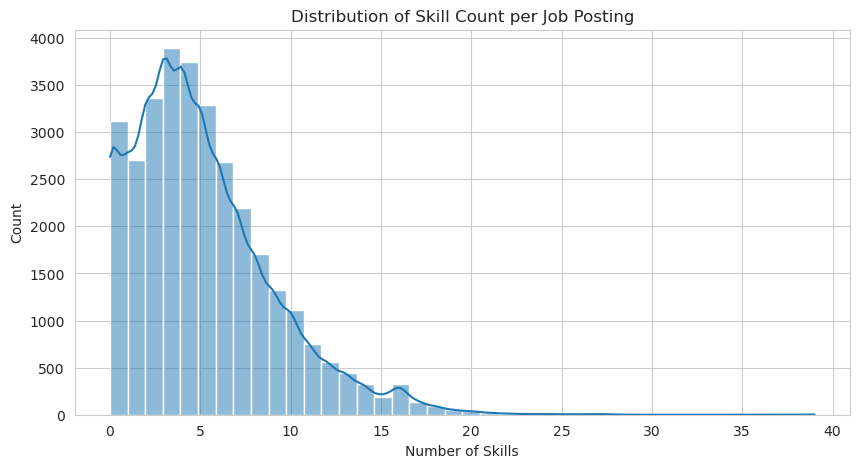

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(jobs_model["skill_count"], bins=40, kde=True)
plt.title("Distribution of Skill Count per Job Posting")
plt.xlabel("Number of Skills")
plt.ylabel("Count")
plt.show()

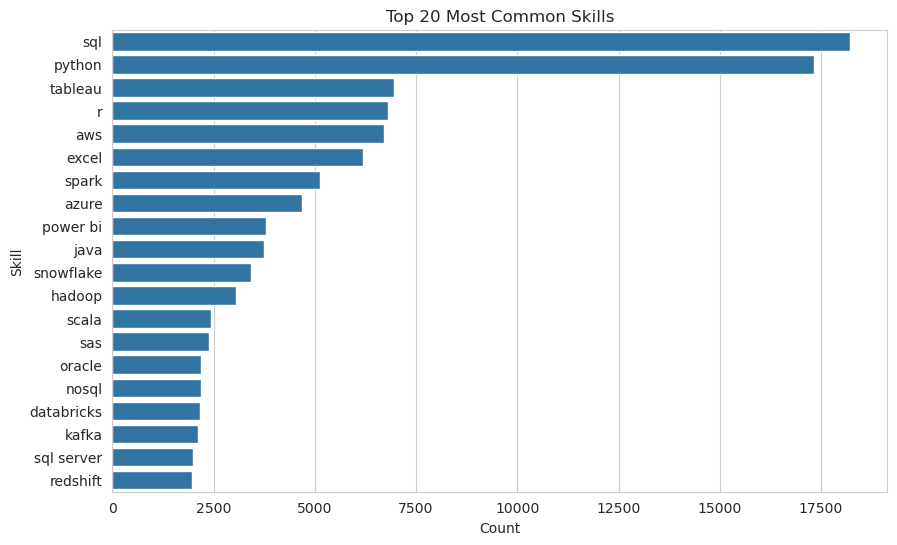

,Skill,Count
0,sql,18225
1,python,17321
2,tableau,6967
3,r,6796
4,aws,6702
5,excel,6200
6,spark,5140
7,azure,4679
8,power bi,3793
9,java,3748


In [23]:
all_skills = [skill for skill_list in jobs_model["skills_list"] for skill in skill_list]
skill_freq = Counter(all_skills)

top_skill_counts = pd.DataFrame(skill_freq.most_common(20), columns=["Skill", "Count"])

plt.figure(figsize=(10, 6))
sns.barplot(data=top_skill_counts, x="Count", y="Skill")
plt.title("Top 20 Most Common Skills")
plt.xlabel("Count")
plt.ylabel("Skill")
plt.show()

display(top_skill_counts)

In [24]:
skill_category_cols = [f"{cat}_count" for cat in skill_type_categories] + ["num_skill_categories"]

display(jobs_model[skill_category_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
analyst_tools_count,32101.0,0.961497,1.333821,0.0,0.0,0.0,2.0,10.0
cloud_count,32101.0,0.749322,1.155938,0.0,0.0,0.0,1.0,9.0
libraries_count,32101.0,0.709261,1.331145,0.0,0.0,0.0,1.0,15.0
databases_count,32101.0,0.207813,0.591336,0.0,0.0,0.0,0.0,8.0
programming_count,32101.0,2.027569,1.731660,0.0,1.0,2.0,3.0,12.0
other_count,32101.0,0.294383,0.735781,0.0,0.0,0.0,0.0,8.0
webframeworks_count,32101.0,0.051743,0.263989,0.0,0.0,0.0,0.0,5.0
os_count,32101.0,0.061431,0.286936,0.0,0.0,0.0,0.0,4.0
async_count,32101.0,0.050154,0.268447,0.0,0.0,0.0,0.0,4.0
sync_count,32101.0,0.013302,0.123717,0.0,0.0,0.0,0.0,3.0


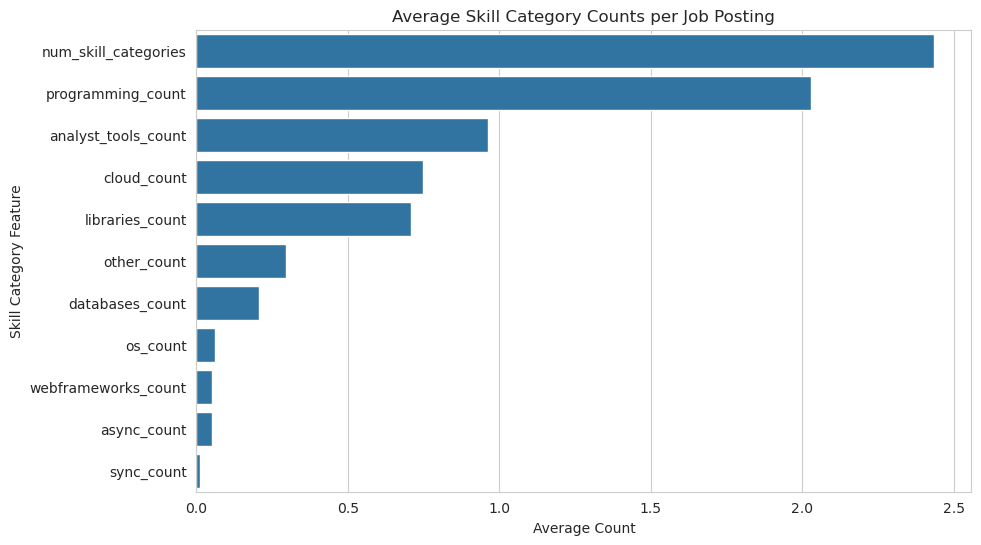

In [25]:
mean_counts = jobs_model[skill_category_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=mean_counts.values, y=mean_counts.index)
plt.title("Average Skill Category Counts per Job Posting")
plt.xlabel("Average Count")
plt.ylabel("Skill Category Feature")
plt.show()

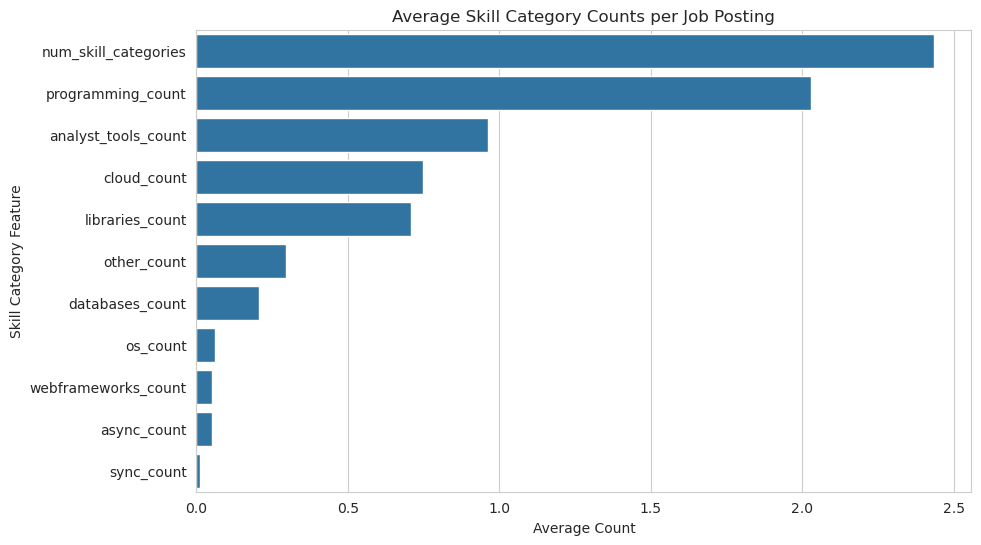

In [26]:
mean_counts = jobs_model[skill_category_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=mean_counts.values, y=mean_counts.index)
plt.title("Average Skill Category Counts per Job Posting")
plt.xlabel("Average Count")
plt.ylabel("Skill Category Feature")
plt.show()

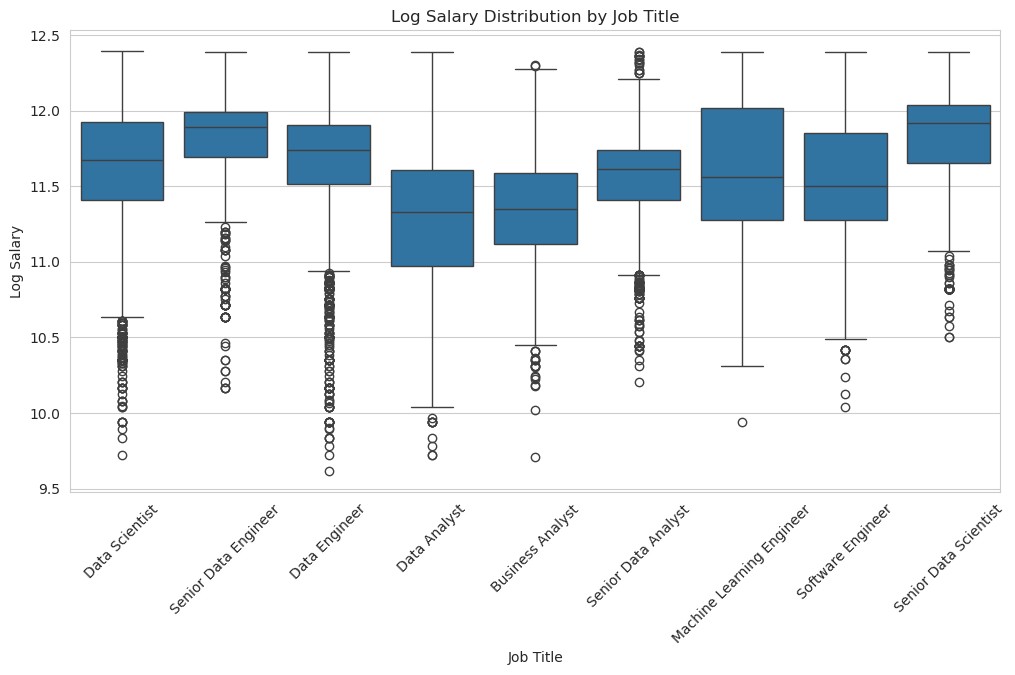

In [27]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=jobs_model, x="job_title_short", y="salary_log")
plt.title("Log Salary Distribution by Job Title")
plt.xlabel("Job Title")
plt.ylabel("Log Salary")
plt.xticks(rotation=45)
plt.show()

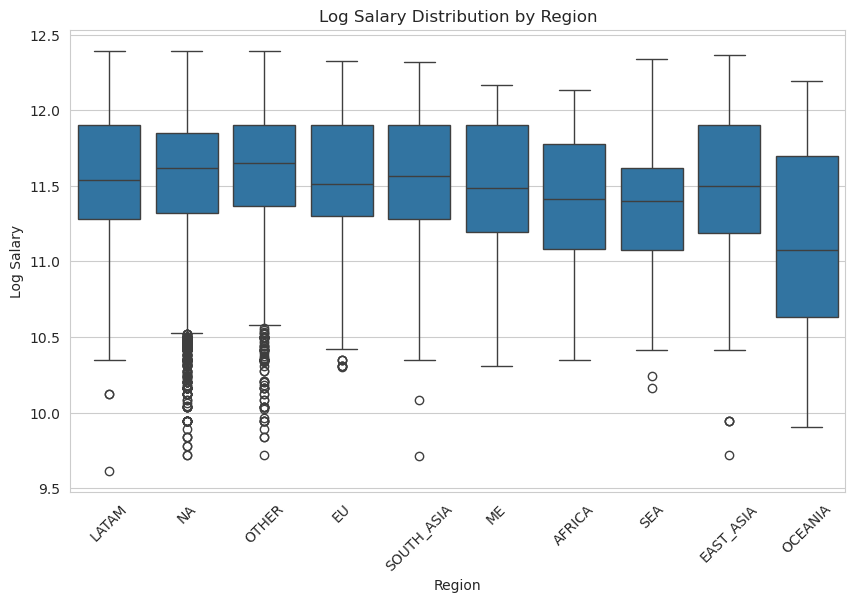

In [28]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=jobs_model, x="region", y="salary_log")
plt.title("Log Salary Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Log Salary")
plt.xticks(rotation=45)
plt.show()

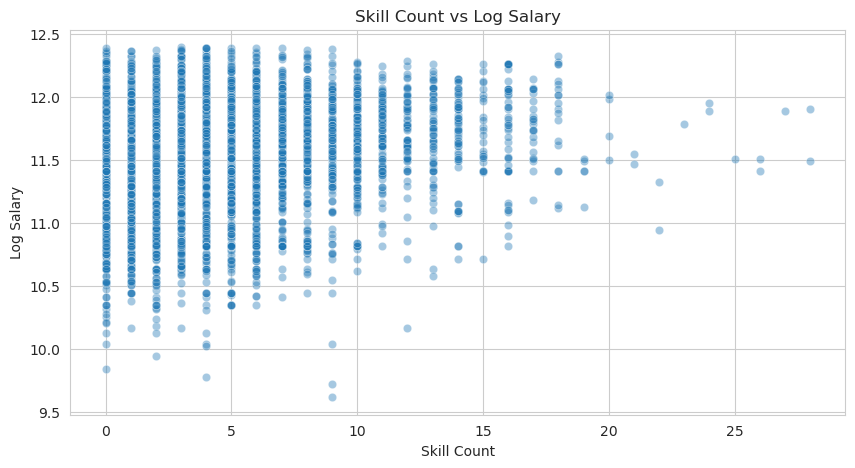

In [29]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=jobs_model.sample(min(5000, len(jobs_model)), random_state=42),
                x="skill_count", y="salary_log", alpha=0.4)
plt.title("Skill Count vs Log Salary")
plt.xlabel("Skill Count")
plt.ylabel("Log Salary")
plt.show()

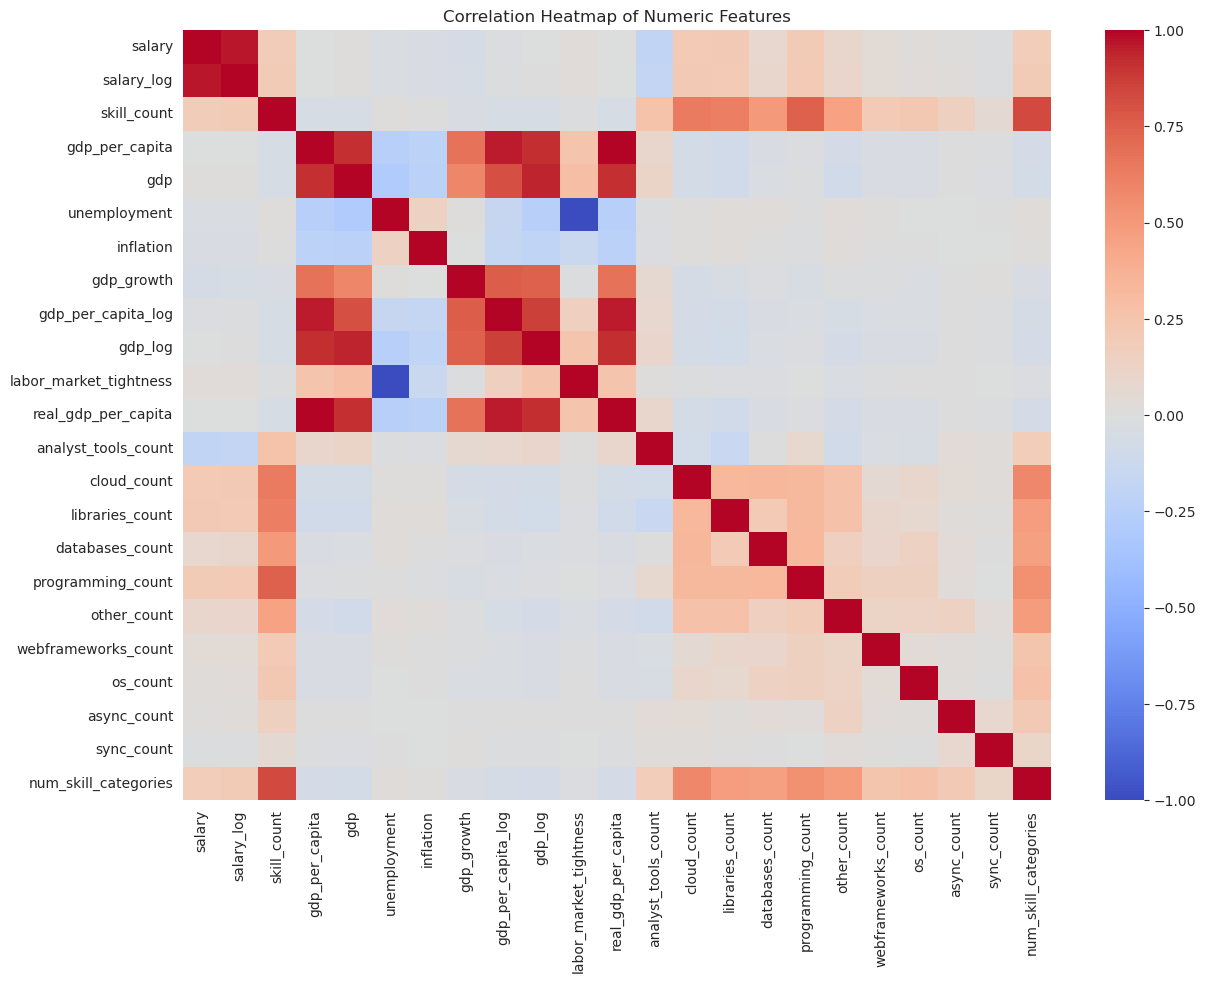

In [30]:
numeric_cols_for_corr = [
    "salary",
    "salary_log",
    "skill_count",
    "gdp_per_capita",
    "gdp",
    "unemployment",
    "inflation",
    "gdp_growth",
    "gdp_per_capita_log",
    "gdp_log",
    "labor_market_tightness",
    "real_gdp_per_capita",
    "analyst_tools_count",
    "cloud_count",
    "libraries_count",
    "databases_count",
    "programming_count",
    "other_count",
    "webframeworks_count",
    "os_count",
    "async_count",
    "sync_count",
    "num_skill_categories"
]

numeric_cols_for_corr = [c for c in numeric_cols_for_corr if c in jobs_model.columns]

corr_matrix = jobs_model[numeric_cols_for_corr].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

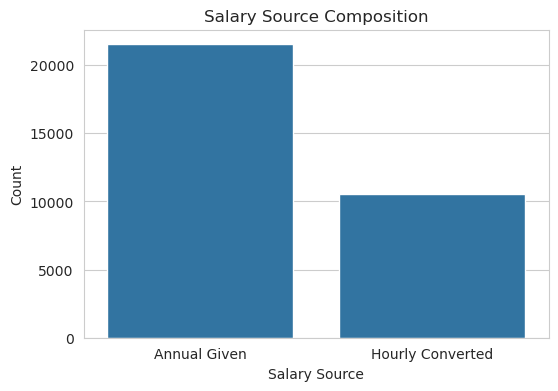

Annual Given        21524
Hourly Converted    10577
Name: count, dtype: int64

In [31]:
salary_source = pd.Series(np.where(jobs_model["salary_year_avg"].notna(), "Annual Given", "Hourly Converted"))
salary_source_counts = salary_source.value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=salary_source_counts.index, y=salary_source_counts.values)
plt.title("Salary Source Composition")
plt.xlabel("Salary Source")
plt.ylabel("Count")
plt.show()

display(salary_source_counts)

# Additional Feature Engineering After EDA

Based on the EDA findings, several additional features are created to better capture salary structure:

- grouped country feature to reduce strong regional imbalance
- title seniority indicators
- title complexity features
- grouped technical stacks such as cloud, visualization, and machine learning tools

These features are added before data splitting so that they can be carried consistently through all modeling methods.

In [32]:
# -------------------------
# ADD COUNTRY GROUPING
# -------------------------
top_countries_global = jobs_model["job_country"].value_counts().head(20).index.tolist()

jobs_model["country_grouped"] = jobs_model["job_country"].where(
    jobs_model["job_country"].isin(top_countries_global),
    "OTHER"
)

# -------------------------
# TITLE FEATURES
# -------------------------
jobs_model["job_title_clean"] = jobs_model["job_title"].fillna("").astype(str).str.lower()

jobs_model["is_senior"] = jobs_model["job_title_clean"].str.contains(r"\bsenior\b", regex=True).astype(int)
jobs_model["is_lead"] = jobs_model["job_title_clean"].str.contains(r"\blead\b", regex=True).astype(int)
jobs_model["is_principal"] = jobs_model["job_title_clean"].str.contains(r"\bprincipal\b", regex=True).astype(int)
jobs_model["is_manager"] = jobs_model["job_title_clean"].str.contains(r"\bmanager\b", regex=True).astype(int)
jobs_model["is_junior"] = jobs_model["job_title_clean"].str.contains(r"\bjunior\b", regex=True).astype(int)
jobs_model["is_intern"] = jobs_model["job_title_clean"].str.contains(r"\bintern\b", regex=True).astype(int)

jobs_model["title_length"] = jobs_model["job_title"].fillna("").astype(str).apply(len)
jobs_model["title_word_count"] = jobs_model["job_title"].fillna("").astype(str).apply(lambda x: len(x.split()))

# -------------------------
# STACK FEATURES FROM skills_list
# -------------------------
jobs_model["cloud_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["aws", "azure", "gcp", "databricks"])
)

jobs_model["visualization_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["tableau", "power bi", "looker", "qlik"])
)

jobs_model["ml_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["tensorflow", "pytorch", "scikit-learn", "keras"])
)

jobs_model["big_data_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["spark", "hadoop", "kafka", "airflow"])
)

jobs_model["core_data_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["sql", "python", "r", "excel"])
)

print("Shape after additional feature engineering:", jobs_model.shape)
display(jobs_model.head())

Shape after additional feature engineering: (32101, 57)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,is_manager,is_junior,is_intern,title_length,title_word_count,cloud_stack,visualization_stack,ml_stack,big_data_stack,core_data_stack
28,Data Scientist,CRM Data Specialist,"San José Province, San José, Costa Rica",via Ai-Jobs.net,Full-time,False,False,False,Costa Rica,year,...,0,0,0,19,3,0,0,0,0,1
43,Senior Data Engineer,Sr SQL Database Engineer with Data Warehouse /...,NaN,via LinkedIn,Contractor,False,True,False,United States,hour,...,0,0,0,60,10,0,0,0,0,1
51,Senior Data Engineer,Senior Data Engineer,Anywhere,via LinkedIn,Contractor,True,False,False,United States,hour,...,0,0,0,20,3,2,0,0,1,1
77,Data Engineer,Data Engineer,"Arlington, VA",via LinkedIn,Full-time,False,False,False,Sudan,year,...,0,0,0,13,2,0,1,0,1,3
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,False,True,United States,year,...,0,0,0,39,8,0,0,0,0,2


# Train / Validation / Test Split

The dataset is split into:
- 70% training
- 15% validation
- 15% test

This allows model training, tuning, and final evaluation on separate data partitions.

In [33]:
train_idx, temp_idx = train_test_split(
    jobs_model.index,
    test_size=0.30,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42
)

train_df = jobs_model.loc[train_idx].copy()
val_df = jobs_model.loc[val_idx].copy()
test_df = jobs_model.loc[test_idx].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (22470, 57)
Validation shape: (4815, 57)
Test shape: (4816, 57)


# Shared Tabular Features

These features are used across all modeling methods and include:
- numeric contextual variables
- engineered skill-category counts
- title features
- binary job attributes
- one-hot encoded categorical variables

In [34]:
common_numeric = [
    "skill_count",
    "gdp_per_capita_log",
    "gdp_log",
    "labor_market_tightness",
    "real_gdp_per_capita",
    "unemployment",
    "inflation",
    "gdp_growth",
    "analyst_tools_count",
    "cloud_count",
    "libraries_count",
    "databases_count",
    "programming_count",
    "other_count",
    "webframeworks_count",
    "os_count",
    "async_count",
    "sync_count",
    "num_skill_categories",
    "cloud_stack",
    "visualization_stack",
    "ml_stack",
    "big_data_stack",
    "core_data_stack",
    "title_length",
    "title_word_count",
    "is_senior",
    "is_lead",
    "is_principal",
    "is_manager",
    "is_junior",
    "is_intern"
]
common_numeric = [c for c in common_numeric if c in jobs_model.columns]

common_categorical = ["region", "job_title_short", "job_schedule_type", "country_grouped"]
common_categorical = [c for c in common_categorical if c in jobs_model.columns]

common_binary = ["job_work_from_home", "job_no_degree_mention", "job_health_insurance"]
common_binary = [c for c in common_binary if c in jobs_model.columns]

tabular_df = jobs_model[common_numeric + common_categorical + common_binary].copy()

tabular_df = pd.get_dummies(tabular_df, columns=common_categorical, drop_first=False)

for c in common_binary:
    if c in tabular_df.columns:
        tabular_df[c] = tabular_df[c].fillna(False).astype(int)

tabular_train = tabular_df.loc[train_idx].copy()
tabular_val = tabular_df.loc[val_idx].copy()
tabular_test = tabular_df.loc[test_idx].copy()

y_train = train_df["salary_log"].copy()
y_val = val_df["salary_log"].copy()
y_test = test_df["salary_log"].copy()

y_val_real = np.expm1(y_val)
y_test_real = np.expm1(y_test)

print("Tabular train shape:", tabular_train.shape)
print("Tabular validation shape:", tabular_val.shape)
print("Tabular test shape:", tabular_test.shape)

Tabular train shape: (22470, 101)
Tabular validation shape: (4815, 101)
Tabular test shape: (4816, 101)


# Cross-Validation Setup

A 5-fold cross-validation object is defined for later evaluation and hyperparameter tuning.

In [35]:
from sklearn.model_selection import KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)
print(cv)

KFold(n_splits=5, random_state=42, shuffle=True)


# Helper Functions

These helper functions standardize regression evaluation and feature construction.

In [36]:
def regression_metrics(y_true_log, pred_log):
    pred_real = np.expm1(pred_log)
    true_real = np.expm1(y_true_log)
    return {
        "R2": r2_score(y_true_log, pred_log),
        "MAE": mean_absolute_error(true_real, pred_real),
        "RMSE": np.sqrt(mean_squared_error(true_real, pred_real))
    }

def evaluate_dense_models(method_name, X_train, X_eval, y_train, y_eval):
    results = []

    models = {
        "Random Forest": RandomForestRegressor(
            n_estimators=500,
            max_depth=18,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ),
        "HistGradientBoosting": HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_depth=8,
            max_iter=400,
            l2_regularization=0.1,
            random_state=42
        ),
        "XGBoost": XGBRegressor(
            objective="reg:squarederror",
            n_estimators=1200,
            learning_rate=0.03,
            max_depth=6,
            min_child_weight=3,
            subsample=0.85,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.5,
            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        )
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred_log = model.predict(X_eval)
        m = regression_metrics(y_eval, pred_log)
        results.append({
            "Method": method_name,
            "Model": name,
            **m
        })

    return pd.DataFrame(results).sort_values("R2", ascending=False)

def make_top_skill_matrix(train_skills, other_skills, top_n=150):
    mlb = MultiLabelBinarizer()

    train_matrix = mlb.fit_transform(train_skills)
    train_df_sk = pd.DataFrame(train_matrix, columns=mlb.classes_, index=train_skills.index)

    top_skills = train_df_sk.sum().sort_values(ascending=False).head(top_n).index.tolist()
    train_df_sk = train_df_sk[top_skills]

    other_matrix = mlb.transform(other_skills)
    other_df_sk = pd.DataFrame(other_matrix, columns=mlb.classes_, index=other_skills.index)

    for c in top_skills:
        if c not in other_df_sk.columns:
            other_df_sk[c] = 0

    other_df_sk = other_df_sk[top_skills]
    return train_df_sk, other_df_sk, top_skills

# Method A: Baseline Multi-Hot Skill Features

This baseline method uses:
- shared tabular features
- top 150 multi-hot encoded skills
- grouped skill-family counts

In [37]:
# Correct train / val skill matrices
skill_train_A, skill_val_A, top_skills_A = make_top_skill_matrix(
    train_df["skills_list"],
    val_df["skills_list"],
    top_n=150
)

# Correct test skill matrix
_, skill_test_A, _ = make_top_skill_matrix(
    train_df["skills_list"],
    test_df["skills_list"],
    top_n=150
)

print(skill_train_A.shape, skill_val_A.shape, skill_test_A.shape)

for df_sk in [skill_train_A, skill_val_A, skill_test_A]:
    for col in ["aws", "azure", "gcp", "tableau", "power bi", "looker", "qlik",
                "tensorflow", "pytorch", "scikit-learn", "keras"]:
        if col not in df_sk.columns:
            df_sk[col] = 0

skill_train_A["cloud_skills"] = skill_train_A[["aws", "azure", "gcp"]].sum(axis=1)
skill_val_A["cloud_skills"] = skill_val_A[["aws", "azure", "gcp"]].sum(axis=1)
skill_test_A["cloud_skills"] = skill_test_A[["aws", "azure", "gcp"]].sum(axis=1)

skill_train_A["bi_tools"] = skill_train_A[["tableau", "power bi", "looker", "qlik"]].sum(axis=1)
skill_val_A["bi_tools"] = skill_val_A[["tableau", "power bi", "looker", "qlik"]].sum(axis=1)
skill_test_A["bi_tools"] = skill_test_A[["tableau", "power bi", "looker", "qlik"]].sum(axis=1)

skill_train_A["ml_tools"] = skill_train_A[["tensorflow", "pytorch", "scikit-learn", "keras"]].sum(axis=1)
skill_val_A["ml_tools"] = skill_val_A[["tensorflow", "pytorch", "scikit-learn", "keras"]].sum(axis=1)
skill_test_A["ml_tools"] = skill_test_A[["tensorflow", "pytorch", "scikit-learn", "keras"]].sum(axis=1)

X_train_A = pd.concat([tabular_train, skill_train_A], axis=1)
X_val_A = pd.concat([tabular_val, skill_val_A], axis=1)
X_test_A = pd.concat([tabular_test, skill_test_A], axis=1)

baseline_val_results_df = evaluate_dense_models(
    method_name="Baseline Multi-Hot",
    X_train=X_train_A,
    X_eval=X_val_A,
    y_train=y_train,
    y_eval=y_val
)

display(baseline_val_results_df)

/opt/conda/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['chainer', 'fastify'] will be ignored
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['chainer', 'clickup', 'kali', 'suse'] will be ignored
  warnings.warn(


(22470, 150) (4815, 150) (4816, 150)


,Method,Model,R2,MAE,RMSE
2,Baseline Multi-Hot,XGBoost,0.391927,26033.999869,34136.285599
1,Baseline Multi-Hot,HistGradientBoosting,0.365580,26917.271928,34931.081279
0,Baseline Multi-Hot,Random Forest,0.347049,27614.354120,35480.918978


# Cross-Validation on the Baseline Method

The strongest baseline model is evaluated using 5-fold cross-validation on the training data.

In [38]:
baseline_best_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

baseline_cv_scores = cross_val_score(
    baseline_best_model,
    X_train_A,
    y_train,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

print("Baseline XGBoost CV R2 scores:", baseline_cv_scores)
print("Baseline XGBoost mean CV R2:", baseline_cv_scores.mean())

Baseline XGBoost CV R2 scores: [0.37484689 0.40775679 0.39665587 0.40242865 0.38256739]
Baseline XGBoost mean CV R2: 0.39285111746049517


# Method B: Frequent Skill Pair Features

This method adds top co-occurring skill-pair indicators to the baseline feature set.

In [39]:
top_skill_set_B = set(top_skills_A)

train_filtered_skills_B = train_df["skills_list"].apply(
    lambda skills: [s for s in skills if s in top_skill_set_B]
)
val_filtered_skills_B = val_df["skills_list"].apply(
    lambda skills: [s for s in skills if s in top_skill_set_B]
)
test_filtered_skills_B = test_df["skills_list"].apply(
    lambda skills: [s for s in skills if s in top_skill_set_B]
)

pair_counter = Counter()
for skills in train_filtered_skills_B:
    unique_skills = sorted(set(skills))
    pair_counter.update(combinations(unique_skills, 2))

top_pairs = pair_counter.most_common(30)

pair_train_B = pd.DataFrame(index=train_df.index)
pair_val_B = pd.DataFrame(index=val_df.index)
pair_test_B = pd.DataFrame(index=test_df.index)

for pair, _ in top_pairs:
    col_name = f"{pair[0]}__{pair[1]}"
    pair_train_B[col_name] = train_filtered_skills_B.apply(lambda skills: int(pair[0] in skills and pair[1] in skills))
    pair_val_B[col_name] = val_filtered_skills_B.apply(lambda skills: int(pair[0] in skills and pair[1] in skills))
    pair_test_B[col_name] = test_filtered_skills_B.apply(lambda skills: int(pair[0] in skills and pair[1] in skills))

X_train_B = pd.concat([tabular_train, skill_train_A, pair_train_B], axis=1)
X_val_B = pd.concat([tabular_val, skill_val_A, pair_val_B], axis=1)
X_test_B = pd.concat([tabular_test, skill_test_A, pair_test_B], axis=1)

pair_val_results_df = evaluate_dense_models(
    method_name="Skill Pair Features",
    X_train=X_train_B,
    X_eval=X_val_B,
    y_train=y_train,
    y_eval=y_val
)

display(pair_val_results_df)

,Method,Model,R2,MAE,RMSE
2,Skill Pair Features,XGBoost,0.393480,25981.846053,34080.965745
1,Skill Pair Features,HistGradientBoosting,0.375179,26559.233397,34663.332071
0,Skill Pair Features,Random Forest,0.343421,27631.433841,35528.666118


# Method C: NMF Skill Bundles

In [40]:
nmf = NMF(
    n_components=10,
    init="nndsvda",
    max_iter=500,
    random_state=42
)

bundle_train_C = nmf.fit_transform(skill_train_A)
bundle_val_C = nmf.transform(skill_val_A)
bundle_test_C = nmf.transform(skill_test_A)

bundle_train_C = pd.DataFrame(bundle_train_C, columns=[f"bundle_{i}" for i in range(bundle_train_C.shape[1])], index=train_df.index)
bundle_val_C = pd.DataFrame(bundle_val_C, columns=[f"bundle_{i}" for i in range(bundle_val_C.shape[1])], index=val_df.index)
bundle_test_C = pd.DataFrame(bundle_test_C, columns=[f"bundle_{i}" for i in range(bundle_test_C.shape[1])], index=test_df.index)

for i, comp in enumerate(nmf.components_):
    top_idx = np.argsort(comp)[::-1][:10]
    top_terms = skill_train_A.columns[top_idx].tolist()
    print(f"Bundle {i}: {top_terms}")

X_train_C = pd.concat([tabular_train, bundle_train_C], axis=1)
X_val_C = pd.concat([tabular_val, bundle_val_C], axis=1)
X_test_C = pd.concat([tabular_test, bundle_test_C], axis=1)

nmf_val_results_df = evaluate_dense_models(
    method_name="NMF Skill Bundles",
    X_train=X_train_C,
    X_eval=X_val_C,
    y_train=y_train,
    y_eval=y_val
)

display(nmf_val_results_df)

Bundle 0: ['cloud_skills', 'aws', 'snowflake', 'redshift', 'gcp', 'airflow', 'docker', 'terraform', 'git', 'kubernetes']
Bundle 1: ['bi_tools', 'tableau', 'power bi', 'looker', 'qlik', 'alteryx', 'oracle', 'snowflake', 'ssrs', 'bigquery']
Bundle 2: ['ml_tools', 'tensorflow', 'pytorch', 'scikit-learn', 'keras', 'pandas', 'numpy', 'matplotlib', 'git', 'spark']
Bundle 3: ['cloud_skills', 'azure', 'databricks', 'gcp', 'sql server', 'power bi', 'ssis', 'pyspark', 'nosql', 't-sql']
Bundle 4: ['sql', 'sql server', 'snowflake', 'oracle', 'flow', 'ssis', 'go', 'jira', 'bigquery', 'git']
Bundle 5: ['spark', 'hadoop', 'kafka', 'nosql', 'scala', 'redshift', 'snowflake', 'mysql', 'airflow', 'cassandra']
Bundle 6: ['excel', 'powerpoint', 'word', 'outlook', 'sas', 'sharepoint', 'sap', 'vba', 'visio', 'spss']
Bundle 7: ['r', 'sas', 'spss', 'matlab', 'python', 'hadoop', 'tableau', 'sql', 'c++', 'javascript']
Bundle 8: ['python', 'pandas', 'pyspark', 'git', 'numpy', 'airflow', 'github', 'go', 'databrick

,Method,Model,R2,MAE,RMSE
2,NMF Skill Bundles,XGBoost,0.395550,25959.658780,34029.474215
0,NMF Skill Bundles,Random Forest,0.368259,26992.472049,34828.255001
1,NMF Skill Bundles,HistGradientBoosting,0.367067,26800.351327,34829.979695


# Method D: Skill Clustering

In [41]:
co_matrix = skill_train_A.T.dot(skill_train_A)
np.fill_diagonal(co_matrix.values, 0)

n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(co_matrix)

skill_cluster_df = pd.DataFrame({
    "skill": co_matrix.index,
    "cluster": cluster_labels
})

for c in range(n_clusters):
    cluster_skills = skill_cluster_df[skill_cluster_df["cluster"] == c]["skill"].tolist()
    print(f"Cluster {c}: {cluster_skills[:15]}")

cluster_train_D = pd.DataFrame(index=train_df.index)
cluster_val_D = pd.DataFrame(index=val_df.index)
cluster_test_D = pd.DataFrame(index=test_df.index)

for c in range(n_clusters):
    cluster_skills = skill_cluster_df[skill_cluster_df["cluster"] == c]["skill"].tolist()
    valid_skills = [s for s in cluster_skills if s in skill_train_A.columns]

    cluster_train_D[f"cluster_{c}"] = skill_train_A[valid_skills].sum(axis=1)
    cluster_val_D[f"cluster_{c}"] = skill_val_A[valid_skills].sum(axis=1)
    cluster_test_D[f"cluster_{c}"] = skill_test_A[valid_skills].sum(axis=1)

X_train_D = pd.concat([tabular_train, cluster_train_D], axis=1)
X_val_D = pd.concat([tabular_val, cluster_val_D], axis=1)
X_test_D = pd.concat([tabular_test, cluster_test_D], axis=1)

cluster_val_results_df = evaluate_dense_models(
    method_name="Skill Clustering",
    X_train=X_train_D,
    X_eval=X_val_D,
    y_train=y_train,
    y_eval=y_val
)

display(cluster_val_results_df)

Cluster 0: ['go', 'word', 'tensorflow', 'flow', 'powerpoint', 'pandas', 'pytorch', 'pyspark', 'javascript', 'kubernetes', 'looker', 'shell', 'c++', 'jira', 'bigquery']
Cluster 1: ['tableau', 'r', 'excel', 'power bi']
Cluster 2: ['aws', 'spark', 'azure']
Cluster 3: ['sql']
Cluster 4: ['cloud_skills']
Cluster 5: ['bi_tools']
Cluster 6: ['python']
Cluster 7: ['java', 'snowflake', 'hadoop', 'scala', 'sas', 'nosql', 'databricks', 'oracle', 'kafka', 'sql server', 'redshift', 'airflow', 'git', 'gcp', 'docker']


,Method,Model,R2,MAE,RMSE
2,Skill Clustering,XGBoost,0.379671,26350.080017,34370.652889
0,Skill Clustering,Random Forest,0.359796,27249.919487,35050.674504
1,Skill Clustering,HistGradientBoosting,0.352590,27291.439919,35229.809586


# Method E: Truncated SVD Skill Compression

In [42]:
svd = TruncatedSVD(n_components=20, random_state=42)

svd_train_E = svd.fit_transform(skill_train_A)
svd_val_E = svd.transform(skill_val_A)
svd_test_E = svd.transform(skill_test_A)

print("Explained variance ratio sum:", svd.explained_variance_ratio_.sum())

svd_train_E = pd.DataFrame(svd_train_E, columns=[f"svd_skill_{i}" for i in range(svd_train_E.shape[1])], index=train_df.index)
svd_val_E = pd.DataFrame(svd_val_E, columns=[f"svd_skill_{i}" for i in range(svd_val_E.shape[1])], index=val_df.index)
svd_test_E = pd.DataFrame(svd_test_E, columns=[f"svd_skill_{i}" for i in range(svd_test_E.shape[1])], index=test_df.index)

X_train_E = pd.concat([tabular_train, svd_train_E], axis=1)
X_val_E = pd.concat([tabular_val, svd_val_E], axis=1)
X_test_E = pd.concat([tabular_test, svd_test_E], axis=1)

svd_val_results_df = evaluate_dense_models(
    method_name="Truncated SVD",
    X_train=X_train_E,
    X_eval=X_val_E,
    y_train=y_train,
    y_eval=y_val
)

display(svd_val_results_df)

Explained variance ratio sum: 0.7209056172827777


,Method,Model,R2,MAE,RMSE
2,Truncated SVD,XGBoost,0.396760,25873.719473,33917.987651
1,Truncated SVD,HistGradientBoosting,0.378693,26443.291075,34479.708886
0,Truncated SVD,Random Forest,0.365167,26879.339293,34812.067588


# Method F: Enhanced Hybrid with Text Features

In [43]:
train_text_F = (
    train_df["job_title"].fillna("").astype(str) + " " +
    train_df["skills_list"].apply(lambda x: " ".join(x))
)

val_text_F = (
    val_df["job_title"].fillna("").astype(str) + " " +
    val_df["skills_list"].apply(lambda x: " ".join(x))
)

test_text_F = (
    test_df["job_title"].fillna("").astype(str) + " " +
    test_df["skills_list"].apply(lambda x: " ".join(x))
)

tfidf_F = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_text_train_F = tfidf_F.fit_transform(train_text_F)
X_text_val_F = tfidf_F.transform(val_text_F)
X_text_test_F = tfidf_F.transform(test_text_F)

text_svd_F = TruncatedSVD(n_components=100, random_state=42)

text_train_F = text_svd_F.fit_transform(X_text_train_F)
text_val_F = text_svd_F.transform(X_text_val_F)
text_test_F = text_svd_F.transform(X_text_test_F)

text_train_F = pd.DataFrame(text_train_F, columns=[f"text_svd_{i}" for i in range(text_train_F.shape[1])], index=train_df.index)
text_val_F = pd.DataFrame(text_val_F, columns=[f"text_svd_{i}" for i in range(text_val_F.shape[1])], index=val_df.index)
text_test_F = pd.DataFrame(text_test_F, columns=[f"text_svd_{i}" for i in range(text_test_F.shape[1])], index=test_df.index)

X_train_F = pd.concat([tabular_train, skill_train_A, pair_train_B, text_train_F], axis=1)
X_val_F = pd.concat([tabular_val, skill_val_A, pair_val_B, text_val_F], axis=1)
X_test_F = pd.concat([tabular_test, skill_test_A, pair_test_B, text_test_F], axis=1)

hybrid_val_results_df = evaluate_dense_models(
    method_name="Enhanced Hybrid",
    X_train=X_train_F,
    X_eval=X_val_F,
    y_train=y_train,
    y_eval=y_val
)

display(hybrid_val_results_df)

,Method,Model,R2,MAE,RMSE
2,Enhanced Hybrid,XGBoost,0.448686,24381.517933,32327.397341
1,Enhanced Hybrid,HistGradientBoosting,0.423785,25348.353926,33098.896905
0,Enhanced Hybrid,Random Forest,0.394954,26025.475387,33946.753434


# Compare Validation Results

In [44]:
all_val_results_df = pd.concat([
    baseline_val_results_df,
    pair_val_results_df,
    nmf_val_results_df,
    cluster_val_results_df,
    svd_val_results_df,
    hybrid_val_results_df
], ignore_index=True)

all_val_results_df = all_val_results_df.sort_values(["R2", "MAE"], ascending=[False, True]).reset_index(drop=True)

display(all_val_results_df)

,Method,Model,R2,MAE,RMSE
0,Enhanced Hybrid,XGBoost,0.448686,24381.517933,32327.397341
1,Enhanced Hybrid,HistGradientBoosting,0.423785,25348.353926,33098.896905
2,Truncated SVD,XGBoost,0.396760,25873.719473,33917.987651
3,NMF Skill Bundles,XGBoost,0.395550,25959.658780,34029.474215
4,Enhanced Hybrid,Random Forest,0.394954,26025.475387,33946.753434
5,Skill Pair Features,XGBoost,0.393480,25981.846053,34080.965745
6,Baseline Multi-Hot,XGBoost,0.391927,26033.999869,34136.285599
7,Skill Clustering,XGBoost,0.379671,26350.080017,34370.652889
8,Truncated SVD,HistGradientBoosting,0.378693,26443.291075,34479.708886
9,Skill Pair Features,HistGradientBoosting,0.375179,26559.233397,34663.332071


# Hyperparameter Tuning on Best Hybrid Method

In [45]:
from sklearn.model_selection import RandomizedSearchCV

xgb_tuned = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

param_grid = {
    "n_estimators": [800, 1000, 1200, 1500],
    "learning_rate": [0.01, 0.02, 0.03],
    "max_depth": [5, 6, 7],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "reg_alpha": [0, 0.05, 0.1, 0.5],
    "reg_lambda": [1, 1.5, 2, 3],
    "gamma": [0, 0.05, 0.1, 0.2]
}

search = RandomizedSearchCV(
    estimator=xgb_tuned,
    param_distributions=param_grid,
    n_iter=20,
    scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"],
    refit="r2",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_F, y_train)

print("Best params:", search.best_params_)
print("Best CV R2:", search.best_score_)

best_xgb_model = search.best_estimator_
best_xgb_model.fit(X_train_F, y_train)
best_xgb_pred_val = best_xgb_model.predict(X_val_F)

tuned_val_metrics = regression_metrics(y_val, best_xgb_pred_val)

tuned_xgb_val_results_df = pd.DataFrame([{
    "Method": "Tuned Hybrid XGBoost",
    "Model": "XGBoost",
    "R2": tuned_val_metrics["R2"],
    "MAE": tuned_val_metrics["MAE"],
    "RMSE": tuned_val_metrics["RMSE"]
}])

display(tuned_xgb_val_results_df)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 0.05, 'n_estimators': 1500, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.02, 'gamma': 0.1, 'colsample_bytree': 0.9}
Best CV R2: 0.4485656531295506


,Method,Model,R2,MAE,RMSE
0,Tuned Hybrid XGBoost,XGBoost,0.453322,24140.322474,32154.541502


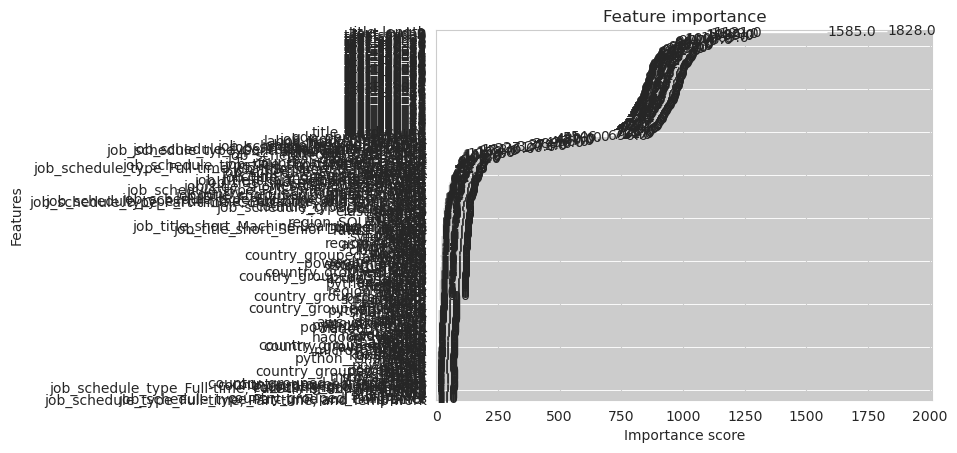

In [46]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(best_xgb_model)
plt.show()

# Advanced Machine Learning Experiments

This section builds a stronger hybrid representation using:
- enriched tabular features
- top skill multi-hot features
- skill pair indicators
- text embeddings
- Word2Vec skill embeddings

In [48]:
from sklearn.ensemble import ExtraTreesRegressor, StackingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
!pip install gensim

try:
    from gensim.models import Word2Vec
    GENSIM_AVAILABLE = True
except ImportError:
    GENSIM_AVAILABLE = False
    print("gensim is not installed. Install it first with: pip install gensim")

In [49]:
if GENSIM_AVAILABLE:
    skill_sentences = train_df["skills_list"].tolist()

    w2v_model = Word2Vec(
        sentences=skill_sentences,
        vector_size=50,
        window=5,
        min_count=1,
        workers=4,
        sg=1,
        epochs=30
    )

    def average_skill_embedding(skills, model, vector_size=50):
        valid_vectors = [model.wv[s] for s in skills if s in model.wv]
        if len(valid_vectors) == 0:
            return np.zeros(vector_size)
        return np.mean(valid_vectors, axis=0)

    skill_embed_train = np.vstack(train_df["skills_list"].apply(lambda x: average_skill_embedding(x, w2v_model, 50)).values)
    skill_embed_val = np.vstack(val_df["skills_list"].apply(lambda x: average_skill_embedding(x, w2v_model, 50)).values)
    skill_embed_test = np.vstack(test_df["skills_list"].apply(lambda x: average_skill_embedding(x, w2v_model, 50)).values)

    skill_embed_train = pd.DataFrame(skill_embed_train, columns=[f"skill_embed_{i}" for i in range(skill_embed_train.shape[1])], index=train_df.index)
    skill_embed_val = pd.DataFrame(skill_embed_val, columns=[f"skill_embed_{i}" for i in range(skill_embed_val.shape[1])], index=val_df.index)
    skill_embed_test = pd.DataFrame(skill_embed_test, columns=[f"skill_embed_{i}" for i in range(skill_embed_test.shape[1])], index=test_df.index)

    X_train_super = pd.concat([tabular_train, skill_train_A, pair_train_B, text_train_F, skill_embed_train], axis=1)
    X_val_super = pd.concat([tabular_val, skill_val_A, pair_val_B, text_val_F, skill_embed_val], axis=1)
    X_test_super = pd.concat([tabular_test, skill_test_A, pair_test_B, text_test_F, skill_embed_test], axis=1)

    scaler_super = StandardScaler()
    X_train_super_scaled = scaler_super.fit_transform(X_train_super)
    X_val_super_scaled = scaler_super.transform(X_val_super)

    models_super = {
        "ExtraTrees": ExtraTreesRegressor(
            n_estimators=800,
            max_depth=None,
            min_samples_split=4,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ),
        "HistGradientBoosting": HistGradientBoostingRegressor(
            learning_rate=0.04,
            max_depth=8,
            max_iter=500,
            l2_regularization=0.1,
            random_state=42
        ),
        "XGBoost": XGBRegressor(
            objective="reg:squarederror",
            n_estimators=1500,
            learning_rate=0.02,
            max_depth=6,
            min_child_weight=3,
            subsample=0.85,
            colsample_bytree=0.8,
            reg_alpha=0.05,
            reg_lambda=1.5,
            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        ),
        "MLP": MLPRegressor(
            hidden_layer_sizes=(256, 128, 64),
            activation="relu",
            solver="adam",
            alpha=0.0005,
            learning_rate_init=0.001,
            max_iter=300,
            random_state=42
        )
    }

    super_results = []

    for name, model in models_super.items():
        if name == "MLP":
            model.fit(X_train_super_scaled, y_train)
            pred_log = model.predict(X_val_super_scaled)
        else:
            model.fit(X_train_super, y_train)
            pred_log = model.predict(X_val_super)

        m = regression_metrics(y_val, pred_log)
        super_results.append({
            "Method": "Super Hybrid + Embeddings",
            "Model": name,
            "R2": m["R2"],
            "MAE": m["MAE"],
            "RMSE": m["RMSE"]
        })

    super_results_df = pd.DataFrame(super_results).sort_values(["R2", "MAE"], ascending=[False, True])
    display(super_results_df)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


,Method,Model,R2,MAE,RMSE
2,Super Hybrid + Embeddings,XGBoost,0.451703,24324.211962,3.226133e+04
1,Super Hybrid + Embeddings,HistGradientBoosting,0.425869,25380.959545,3.310927e+04
0,Super Hybrid + Embeddings,ExtraTrees,0.425757,24586.049971,3.281770e+04
3,Super Hybrid + Embeddings,MLP,-0.409062,83518.052963,2.965644e+06


In [50]:
if GENSIM_AVAILABLE:
    all_results_final_df = pd.concat([
        all_val_results_df,
        tuned_xgb_val_results_df,
        super_results_df
    ], ignore_index=True)
else:
    all_results_final_df = pd.concat([
        all_val_results_df,
        tuned_xgb_val_results_df
    ], ignore_index=True)

all_results_final_df = all_results_final_df.sort_values(["R2", "MAE"], ascending=[False, True]).reset_index(drop=True)

display(all_results_final_df)

,Method,Model,R2,MAE,RMSE
0,Tuned Hybrid XGBoost,XGBoost,0.453322,24140.322474,3.215454e+04
1,Super Hybrid + Embeddings,XGBoost,0.451703,24324.211962,3.226133e+04
2,Enhanced Hybrid,XGBoost,0.448686,24381.517933,3.232740e+04
3,Super Hybrid + Embeddings,HistGradientBoosting,0.425869,25380.959545,3.310927e+04
4,Super Hybrid + Embeddings,ExtraTrees,0.425757,24586.049971,3.281770e+04
5,Enhanced Hybrid,HistGradientBoosting,0.423785,25348.353926,3.309890e+04
6,Truncated SVD,XGBoost,0.396760,25873.719473,3.391799e+04
7,NMF Skill Bundles,XGBoost,0.395550,25959.658780,3.402947e+04
8,Enhanced Hybrid,Random Forest,0.394954,26025.475387,3.394675e+04
9,Skill Pair Features,XGBoost,0.393480,25981.846053,3.408097e+04


# Final Test Evaluation

After selecting the strongest method on the validation set, the final chosen model should be retrained on train + validation data and then evaluated once on the held-out test set.

In [51]:
# Example: using tuned hybrid XGBoost as final model candidate

trainval_df = pd.concat([train_df, val_df], axis=0)
y_trainval = trainval_df["salary_log"]

tabular_trainval = pd.concat([tabular_train, tabular_val], axis=0)
skill_trainval = pd.concat([skill_train_A, skill_val_A], axis=0)
pair_trainval = pd.concat([pair_train_B, pair_val_B], axis=0)
text_trainval = pd.concat([text_train_F, text_val_F], axis=0)

X_trainval_F = pd.concat([tabular_trainval, skill_trainval, pair_trainval, text_trainval], axis=1)

final_model = search.best_estimator_
final_model.fit(X_trainval_F, y_trainval)

final_pred_test = final_model.predict(X_test_F)
final_test_metrics = regression_metrics(y_test, final_pred_test)

final_test_results_df = pd.DataFrame([{
    "Method": "Final Tuned Hybrid XGBoost",
    "Model": "XGBoost",
    "R2": final_test_metrics["R2"],
    "MAE": final_test_metrics["MAE"],
    "RMSE": final_test_metrics["RMSE"]
}])

display(final_test_results_df)

,Method,Model,R2,MAE,RMSE
0,Final Tuned Hybrid XGBoost,XGBoost,0.457956,23977.865065,31979.167972


In [52]:
# -------------------------
# EDA-DRIVEN FEATURE ENGINEERING
# -------------------------

# 1. Country grouping (since region alone is too broad)
top_countries_global = jobs_model["job_country"].value_counts().head(20).index.tolist()

jobs_model["country_grouped"] = jobs_model["job_country"].where(
    jobs_model["job_country"].isin(top_countries_global),
    "OTHER"
)

# 2. Seniority / level features from title
jobs_model["job_title_clean"] = jobs_model["job_title"].fillna("").astype(str).str.lower()

jobs_model["is_senior"] = jobs_model["job_title_clean"].str.contains(r"\bsenior\b", regex=True).astype(int)
jobs_model["is_lead"] = jobs_model["job_title_clean"].str.contains(r"\blead\b", regex=True).astype(int)
jobs_model["is_principal"] = jobs_model["job_title_clean"].str.contains(r"\bprincipal\b", regex=True).astype(int)
jobs_model["is_manager"] = jobs_model["job_title_clean"].str.contains(r"\bmanager\b", regex=True).astype(int)
jobs_model["is_junior"] = jobs_model["job_title_clean"].str.contains(r"\bjunior\b", regex=True).astype(int)
jobs_model["is_intern"] = jobs_model["job_title_clean"].str.contains(r"\bintern\b", regex=True).astype(int)

# 3. Title complexity
jobs_model["title_length"] = jobs_model["job_title"].fillna("").astype(str).apply(len)
jobs_model["title_word_count"] = jobs_model["job_title"].fillna("").astype(str).apply(lambda x: len(x.split()))

# 4. Skill stacks (based on EDA top skills)
jobs_model["cloud_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["aws", "azure", "gcp", "databricks"])
)

jobs_model["visualization_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["tableau", "power bi", "looker", "qlik"])
)

jobs_model["ml_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["tensorflow", "pytorch", "scikit-learn", "keras"])
)

jobs_model["big_data_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["spark", "hadoop", "kafka", "airflow"])
)

jobs_model["core_data_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["python", "sql", "r", "excel"])
)

# 5. Nonlinear version of skill count
jobs_model["skill_count_sq"] = jobs_model["skill_count"] ** 2
jobs_model["skill_count_log"] = np.log1p(jobs_model["skill_count"])

print("Shape after EDA-driven feature engineering:", jobs_model.shape)
display(jobs_model.head())

Shape after EDA-driven feature engineering: (32101, 59)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,is_intern,title_length,title_word_count,cloud_stack,visualization_stack,ml_stack,big_data_stack,core_data_stack,skill_count_sq,skill_count_log
28,Data Scientist,CRM Data Specialist,"San José Province, San José, Costa Rica",via Ai-Jobs.net,Full-time,False,False,False,Costa Rica,year,...,0,19,3,0,0,0,0,1,4,1.098612
43,Senior Data Engineer,Sr SQL Database Engineer with Data Warehouse /...,NaN,via LinkedIn,Contractor,False,True,False,United States,hour,...,0,60,10,0,0,0,0,1,4,1.098612
51,Senior Data Engineer,Senior Data Engineer,Anywhere,via LinkedIn,Contractor,True,False,False,United States,hour,...,0,20,3,2,0,0,1,1,25,1.791759
77,Data Engineer,Data Engineer,"Arlington, VA",via LinkedIn,Full-time,False,False,False,Sudan,year,...,0,13,2,0,1,0,1,3,100,2.397895
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,False,True,United States,year,...,0,39,8,0,0,0,0,2,4,1.098612


In [53]:
# -------------------------
# TRAIN / VALIDATION / TEST SPLIT
# -------------------------

train_idx, temp_idx = train_test_split(
    jobs_model.index,
    test_size=0.30,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42
)

train_df = jobs_model.loc[train_idx].copy()
val_df = jobs_model.loc[val_idx].copy()
test_df = jobs_model.loc[test_idx].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (22470, 59)
Validation shape: (4815, 59)
Test shape: (4816, 59)


In [54]:
# -------------------------
# SHARED TABULAR FEATURES
# -------------------------

common_numeric = [
    "skill_count",
    "skill_count_sq",
    "skill_count_log",
    "gdp_per_capita_log",
    "gdp_log",
    "labor_market_tightness",
    "real_gdp_per_capita",
    "unemployment",
    "inflation",
    "gdp_growth",
    "analyst_tools_count",
    "cloud_count",
    "libraries_count",
    "databases_count",
    "programming_count",
    "other_count",
    "webframeworks_count",
    "os_count",
    "async_count",
    "sync_count",
    "num_skill_categories",
    "cloud_stack",
    "visualization_stack",
    "ml_stack",
    "big_data_stack",
    "core_data_stack",
    "title_length",
    "title_word_count",
    "is_senior",
    "is_lead",
    "is_principal",
    "is_manager",
    "is_junior",
    "is_intern"
]
common_numeric = [c for c in common_numeric if c in jobs_model.columns]

common_categorical = [
    "region",
    "country_grouped",
    "job_title_short",
    "job_schedule_type"
]
common_categorical = [c for c in common_categorical if c in jobs_model.columns]

common_binary = [
    "job_work_from_home",
    "job_no_degree_mention",
    "job_health_insurance"
]
common_binary = [c for c in common_binary if c in jobs_model.columns]

tabular_df = jobs_model[common_numeric + common_categorical + common_binary].copy()

tabular_df = pd.get_dummies(
    tabular_df,
    columns=common_categorical,
    drop_first=False
)

for c in common_binary:
    if c in tabular_df.columns:
        tabular_df[c] = tabular_df[c].fillna(False).astype(int)

tabular_train = tabular_df.loc[train_idx].copy()
tabular_val = tabular_df.loc[val_idx].copy()
tabular_test = tabular_df.loc[test_idx].copy()

y_train = train_df["salary_log"].copy()
y_val = val_df["salary_log"].copy()
y_test = test_df["salary_log"].copy()

print("Tabular train shape:", tabular_train.shape)
print("Tabular validation shape:", tabular_val.shape)
print("Tabular test shape:", tabular_test.shape)

Tabular train shape: (22470, 103)
Tabular validation shape: (4815, 103)
Tabular test shape: (4816, 103)


In [55]:
# -------------------------
# CROSS-VALIDATION SETUP
# -------------------------
from sklearn.model_selection import KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)
print(cv)

KFold(n_splits=5, random_state=42, shuffle=True)


In [56]:
# -------------------------
# HELPER FUNCTIONS
# -------------------------

def regression_metrics(y_true_log, pred_log):
    pred_real = np.expm1(pred_log)
    true_real = np.expm1(y_true_log)
    return {
        "R2": r2_score(y_true_log, pred_log),
        "MAE": mean_absolute_error(true_real, pred_real),
        "RMSE": np.sqrt(mean_squared_error(true_real, pred_real))
    }

def evaluate_dense_models(method_name, X_train, X_eval, y_train, y_eval):
    results = []

    models = {
        "Random Forest": RandomForestRegressor(
            n_estimators=500,
            max_depth=18,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ),
        "HistGradientBoosting": HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_depth=8,
            max_iter=400,
            l2_regularization=0.1,
            random_state=42
        ),
        "XGBoost": XGBRegressor(
            objective="reg:squarederror",
            n_estimators=1200,
            learning_rate=0.03,
            max_depth=6,
            min_child_weight=3,
            subsample=0.85,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.5,
            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        )
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred_log = model.predict(X_eval)
        m = regression_metrics(y_eval, pred_log)
        results.append({
            "Method": method_name,
            "Model": name,
            **m
        })

    return pd.DataFrame(results).sort_values("R2", ascending=False)

def make_top_skill_matrix(train_skills, other_skills, top_n=150):
    mlb = MultiLabelBinarizer()

    train_matrix = mlb.fit_transform(train_skills)
    train_df_sk = pd.DataFrame(train_matrix, columns=mlb.classes_, index=train_skills.index)

    top_skills = train_df_sk.sum().sort_values(ascending=False).head(top_n).index.tolist()
    train_df_sk = train_df_sk[top_skills]

    other_matrix = mlb.transform(other_skills)
    other_df_sk = pd.DataFrame(other_matrix, columns=mlb.classes_, index=other_skills.index)

    for c in top_skills:
        if c not in other_df_sk.columns:
            other_df_sk[c] = 0

    other_df_sk = other_df_sk[top_skills]
    return train_df_sk, other_df_sk, top_skills

In [57]:
# -------------------------
# METHOD A: BASELINE MULTI-HOT
# -------------------------

skill_train_A, skill_val_A, top_skills_A = make_top_skill_matrix(
    train_df["skills_list"],
    val_df["skills_list"],
    top_n=150
)

_, skill_test_A, _ = make_top_skill_matrix(
    train_df["skills_list"],
    test_df["skills_list"],
    top_n=150
)

for df_sk in [skill_train_A, skill_val_A, skill_test_A]:
    for col in ["aws", "azure", "gcp", "tableau", "power bi", "looker", "qlik",
                "tensorflow", "pytorch", "scikit-learn", "keras"]:
        if col not in df_sk.columns:
            df_sk[col] = 0

skill_train_A["cloud_skills"] = skill_train_A[["aws", "azure", "gcp"]].sum(axis=1)
skill_val_A["cloud_skills"] = skill_val_A[["aws", "azure", "gcp"]].sum(axis=1)
skill_test_A["cloud_skills"] = skill_test_A[["aws", "azure", "gcp"]].sum(axis=1)

skill_train_A["bi_tools"] = skill_train_A[["tableau", "power bi", "looker", "qlik"]].sum(axis=1)
skill_val_A["bi_tools"] = skill_val_A[["tableau", "power bi", "looker", "qlik"]].sum(axis=1)
skill_test_A["bi_tools"] = skill_test_A[["tableau", "power bi", "looker", "qlik"]].sum(axis=1)

skill_train_A["ml_tools"] = skill_train_A[["tensorflow", "pytorch", "scikit-learn", "keras"]].sum(axis=1)
skill_val_A["ml_tools"] = skill_val_A[["tensorflow", "pytorch", "scikit-learn", "keras"]].sum(axis=1)
skill_test_A["ml_tools"] = skill_test_A[["tensorflow", "pytorch", "scikit-learn", "keras"]].sum(axis=1)

X_train_A = pd.concat([tabular_train, skill_train_A], axis=1)
X_val_A = pd.concat([tabular_val, skill_val_A], axis=1)
X_test_A = pd.concat([tabular_test, skill_test_A], axis=1)

baseline_val_results_df = evaluate_dense_models(
    method_name="Baseline Multi-Hot",
    X_train=X_train_A,
    X_eval=X_val_A,
    y_train=y_train,
    y_eval=y_val
)

display(baseline_val_results_df)

/opt/conda/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['chainer', 'fastify'] will be ignored
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['chainer', 'clickup', 'kali', 'suse'] will be ignored
  warnings.warn(


,Method,Model,R2,MAE,RMSE
2,Baseline Multi-Hot,XGBoost,0.393303,26024.068359,34110.788999
1,Baseline Multi-Hot,HistGradientBoosting,0.365580,26917.271928,34931.081279
0,Baseline Multi-Hot,Random Forest,0.349540,27558.154253,35405.592642


In [58]:
# -------------------------
# 5-FOLD CROSS-VALIDATION ON BEST BASELINE MODEL
# -------------------------

baseline_best_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

baseline_cv_scores = cross_val_score(
    baseline_best_model,
    X_train_A,
    y_train,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

print("Baseline XGBoost CV R2 scores:", baseline_cv_scores)
print("Baseline XGBoost mean CV R2:", baseline_cv_scores.mean())

Baseline XGBoost CV R2 scores: [0.3771693  0.40881343 0.39852635 0.40343418 0.38414326]
Baseline XGBoost mean CV R2: 0.3944173036446779
